<a href="https://colab.research.google.com/github/safnanazar04-cmyk/unsupervised-learning/blob/main/Unsupervised_learning_casestudy_safna.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv('/content/drive/MyDrive/DSA B11/Datasets/adult_dataset (1).csv')

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40.0,NaN,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,39.0,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36.0,United-States,<=50K.
48838,64.0,NaN,321403,HS-grad,9,Widowed,NaN,Other-relative,Black,Male,0,0,40.0,United-States,<=50K.
48839,38.0,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50.0,United-States,<=50K.
48840,44.0,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40.0,United-States,<=50K.


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             46400 non-null  float64
 1   workclass       45480 non-null  object 
 2   fnlwgt          48842 non-null  int64  
 3   education       48842 non-null  object 
 4   education-num   48842 non-null  int64  
 5   marital-status  48842 non-null  object 
 6   occupation      45485 non-null  object 
 7   relationship    48842 non-null  object 
 8   race            48842 non-null  object 
 9   sex             48842 non-null  object 
 10  capital-gain    48842 non-null  int64  
 11  capital-loss    48842 non-null  int64  
 12  hours-per-week  46400 non-null  float64
 13  native-country  46137 non-null  object 
 14  income          48842 non-null  object 
dtypes: float64(2), int64(4), object(9)
memory usage: 5.6+ MB


In [6]:
df.isnull().sum()

,0
age,2442
workclass,3362
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,3357
relationship,0
race,0
sex,0


In [7]:
for col in df.columns:
    print(f"Unique values in '{col}':")
    print(df[col].unique())
    print("-" * 10)

Unique values in 'age':
[ 39.  50.  38.  53.  28.  37.  49.  52.  31.  42.  30.  23.  32.  40.
  34.  25.  nan  54.  35.  43.  59.  56.  19.  20.  45.  22.  48.  21.
  24.  57.  44.  41.  29.  18.  47.  46.  79.  27.  67.  33.  76.  17.
 120.  36.  55.  61.  70.  64.  71.  68.  66.  51.  58.  26.  60.  90.
  75.  65.  77.  62.  63.  80.  74.  72.  69.  73.  81.  88. 250.  78.
  82.  83. 255.  84.  85. 225. 230.  86.  87.  89. 140. 100. 210.]
----------
Unique values in 'workclass':
['State-gov' 'Self-emp-not-inc' 'Private' 'Federal-gov' nan 'Local-gov'
 '?' 'Self-emp-inc' 'Without-pay' 'Never-worked']
----------
Unique values in 'fnlwgt':
[ 77516  83311 215646 ... 173449  89686 350977]
----------
Unique values in 'education':
['Bachelors' 'HS-grad' '11th' 'Masters' '9th' 'Some-college' 'Assoc-acdm'
 'Assoc-voc' '7th-8th' 'Doctorate' 'Prof-school' '5th-6th' '10th'
 '1st-4th' 'Preschool' '12th']
----------
Unique values in 'education-num':
[13  9  7 14  5 10 12 11  4 16 15  3  6  2  1  8

In [8]:
df['workclass'] = df['workclass'].replace('?', np.nan)

In [9]:
df.isnull().sum()

,0
age,2442
workclass,5125
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,3357
relationship,0
race,0
sex,0


In [10]:
num_cols = df.select_dtypes(include=['number']).columns.tolist()

cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

In [11]:
for c in num_cols:
    df[c] = df[c].fillna(df[c].median())

In [12]:
for c in cat_cols:
    df[c] = df[c].fillna(df[c].mode()[0])

In [13]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             48842 non-null  float64
 1   workclass       48842 non-null  object 
 2   fnlwgt          48842 non-null  int64  
 3   education       48842 non-null  object 
 4   education-num   48842 non-null  int64  
 5   marital-status  48842 non-null  object 
 6   occupation      48842 non-null  object 
 7   relationship    48842 non-null  object 
 8   race            48842 non-null  object 
 9   sex             48842 non-null  object 
 10  capital-gain    48842 non-null  int64  
 11  capital-loss    48842 non-null  int64  
 12  hours-per-week  48842 non-null  float64
 13  native-country  48842 non-null  object 
 14  income          48842 non-null  object 
dtypes: float64(2), int64(4), object(9)
memory usage: 5.6+ MB


In [15]:
df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40.0,United-States,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,39.0,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36.0,United-States,<=50K.
48838,64.0,Private,321403,HS-grad,9,Widowed,Prof-specialty,Other-relative,Black,Male,0,0,40.0,United-States,<=50K.
48839,38.0,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50.0,United-States,<=50K.
48840,44.0,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40.0,United-States,<=50K.


In [16]:
outlier_cols = ['age', 'hours-per-week']

for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    print(f"{col}")
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower:", lower_bound)
    print("Upper:", upper_bound)

    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

age
Q1: 28.0
Q3: 47.0
IQR: 19.0
Lower: -0.5
Upper: 75.5
hours-per-week
Q1: 40.0
Q3: 45.0
IQR: 5.0
Lower: 32.5
Upper: 52.5


In [17]:
from sklearn.preprocessing import OneHotEncoder

onehotencoder = OneHotEncoder()
df_encoded = pd.DataFrame(onehotencoder.fit_transform(df[['workclass', 'education', 'occupation', 'native-country']]).toarray(),dtype = int)
df_encoded.columns = onehotencoder.get_feature_names_out(['workclass', 'education', 'occupation', 'native-country'])
df = pd.concat([df, df_encoded], axis=1)
df.drop(['workclass', 'education', 'occupation', 'native-country'], axis=1, inplace=True)

In [18]:
from sklearn.preprocessing import LabelEncoder
labelencoder = LabelEncoder()
df['marital-status'] = labelencoder.fit_transform(df['marital-status'])
df['relationship'] = labelencoder.fit_transform(df['relationship'])
df['race'] = labelencoder.fit_transform(df['race'])
df['sex'] = labelencoder.fit_transform(df['sex'])

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 92 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   age                                        48842 non-null  float64
 1   fnlwgt                                     48842 non-null  int64  
 2   education-num                              48842 non-null  int64  
 3   marital-status                             48842 non-null  int64  
 4   relationship                               48842 non-null  int64  
 5   race                                       48842 non-null  int64  
 6   sex                                        48842 non-null  int64  
 7   capital-gain                               48842 non-null  int64  
 8   capital-loss                               48842 non-null  int64  
 9   hours-per-week                             48842 non-null  float64
 10  income                

In [20]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df.drop('income', axis=1)), columns=df.drop('income', axis=1).columns)

In [21]:
df_scaled

,age,fnlwgt,education-num,marital-status,relationship,race,sex,capital-gain,capital-loss,hours-per-week,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,0.376068,0.044131,0.800000,0.666667,0.2,1.00,1.0,0.021740,0.0,0.375,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.564103,0.048052,0.800000,0.333333,0.0,1.00,1.0,0.000000,0.0,0.000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.358974,0.137581,0.533333,0.000000,0.2,1.00,1.0,0.000000,0.0,0.375,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.615385,0.150486,0.400000,0.333333,0.0,0.50,1.0,0.000000,0.0,0.375,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.188034,0.220635,0.800000,0.333333,1.0,0.50,0.0,0.000000,0.0,0.375,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,0.376068,0.137428,0.800000,0.000000,0.2,1.00,0.0,0.000000,0.0,0.175,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
48838,0.803419,0.209130,0.533333,1.000000,0.4,0.50,1.0,0.000000,0.0,0.375,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
48839,0.358974,0.245379,0.800000,0.333333,0.0,1.00,1.0,0.000000,0.0,0.875,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
48840,0.461538,0.048444,0.800000,0.000000,0.6,0.25,1.0,0.054551,0.0,0.375,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [22]:
from sklearn.decomposition import PCA

from sklearn.decomposition import PCA
pca = PCA(n_components=0.95)
df_pca = pd.DataFrame(pca.fit_transform(df_scaled), columns=[f'PC{i+1}' for i in range(pca.n_components_)])
df_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC26,PC27,PC28,PC29,PC30,PC31,PC32,PC33,PC34,PC35
0,0.445289,-0.566327,-0.526133,-0.115366,-0.547154,0.139670,0.270862,0.830654,-0.739785,0.377053,...,0.485587,-0.140003,-0.152583,-0.071839,0.050617,0.002088,-0.037714,-0.118109,0.005687,0.008465
1,0.896986,-0.609167,-0.550376,-0.144281,-0.907774,0.194634,-0.199821,-0.038547,0.090793,0.411082,...,0.011867,0.008295,-0.123636,0.034950,0.099455,0.037122,-0.018611,0.038348,-0.033389,0.019316
2,0.192135,0.846934,0.065490,0.102768,0.080173,-0.196470,0.009760,-0.088298,-0.180459,0.136026,...,-0.073392,0.027403,-0.197230,0.001567,-0.022889,-0.023408,-0.013396,-0.036166,0.036288,-0.004911
3,0.252037,0.114706,0.402821,0.204414,0.045440,0.310708,-0.146692,-0.061661,-0.238520,-0.062820,...,-0.230820,-0.431848,-0.147144,-0.043668,0.060787,-0.182964,-0.098758,-0.023596,0.004988,0.051063
4,-0.642269,-0.758374,-0.592219,0.977662,0.237363,0.359202,-0.093525,0.154754,-0.016592,-0.408839,...,-0.043838,0.023833,-0.000125,-0.043120,-0.021101,-0.052406,-0.047314,0.072793,0.073969,-0.084189


In [23]:
explained_variance = pca.explained_variance_ratio_

print(explained_variance)

[0.1106643  0.1039876  0.0796586  0.06913247 0.05384695 0.04032861
 0.03833143 0.03709388 0.03362412 0.03187185 0.02903497 0.02602837
 0.02357196 0.02345192 0.02186001 0.01811815 0.01747592 0.01625161
 0.01541366 0.01465742 0.0142633  0.01404146 0.01349895 0.01217741
 0.01189148 0.01149125 0.0106828  0.0100678  0.00983001 0.0088158
 0.00770286 0.00642391 0.00622884 0.00594269 0.00526419]


In [24]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(df_pca)
    wcss.append(kmeans.inertia_)

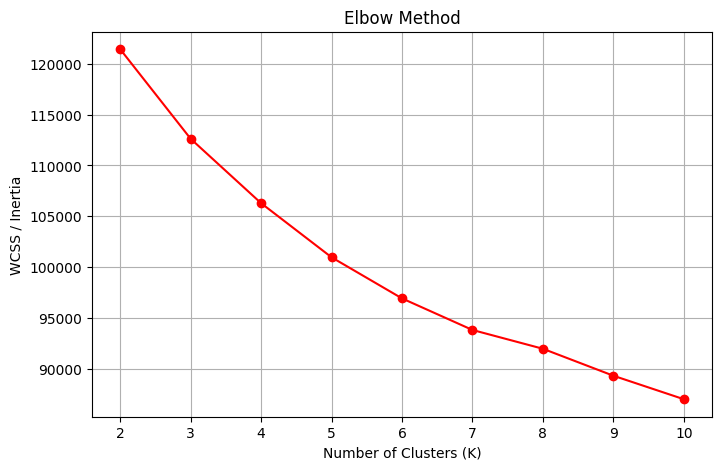

In [25]:
plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), wcss,c='red', marker='o')

plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS / Inertia')
plt.title('Elbow Method')
plt.grid()
plt.show()

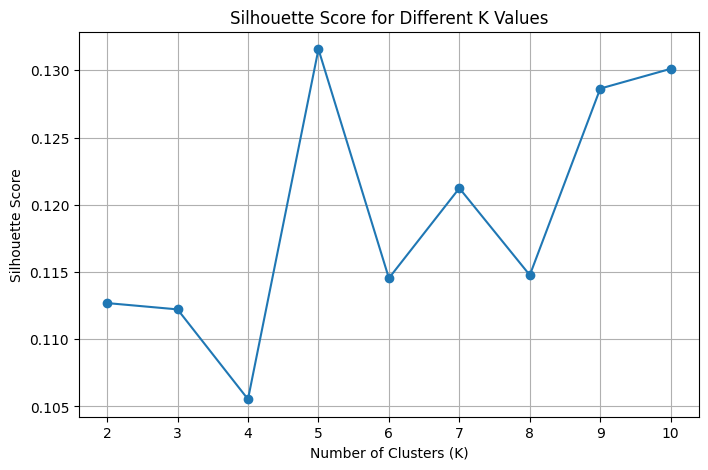

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(df_pca)

    score = silhouette_score(df_pca, labels)
    silhouette_scores.append(score)

# Plot Silhouette Scores
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    silhouette_scores,
    marker='o'
)

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Different K Values')
plt.grid()
plt.show()

In [26]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(df_pca)

df_pca['Cluster'] = cluster_labels

df_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC27,PC28,PC29,PC30,PC31,PC32,PC33,PC34,PC35,Cluster
0,0.445289,-0.566327,-0.526133,-0.115366,-0.547154,0.139670,0.270862,0.830654,-0.739785,0.377053,...,-0.140003,-0.152583,-0.071839,0.050617,0.002088,-0.037714,-0.118109,0.005687,0.008465,2
1,0.896986,-0.609167,-0.550376,-0.144281,-0.907774,0.194634,-0.199821,-0.038547,0.090793,0.411082,...,0.008295,-0.123636,0.034950,0.099455,0.037122,-0.018611,0.038348,-0.033389,0.019316,2
2,0.192135,0.846934,0.065490,0.102768,0.080173,-0.196470,0.009760,-0.088298,-0.180459,0.136026,...,0.027403,-0.197230,0.001567,-0.022889,-0.023408,-0.013396,-0.036166,0.036288,-0.004911,3
3,0.252037,0.114706,0.402821,0.204414,0.045440,0.310708,-0.146692,-0.061661,-0.238520,-0.062820,...,-0.431848,-0.147144,-0.043668,0.060787,-0.182964,-0.098758,-0.023596,0.004988,0.051063,0
4,-0.642269,-0.758374,-0.592219,0.977662,0.237363,0.359202,-0.093525,0.154754,-0.016592,-0.408839,...,0.023833,-0.000125,-0.043120,-0.021101,-0.052406,-0.047314,0.072793,0.073969,-0.084189,2


In [27]:
df_pca['Cluster'].value_counts().sort_index()

,count
Cluster,
0,9783
1,9476
2,8017
3,10688
4,10878


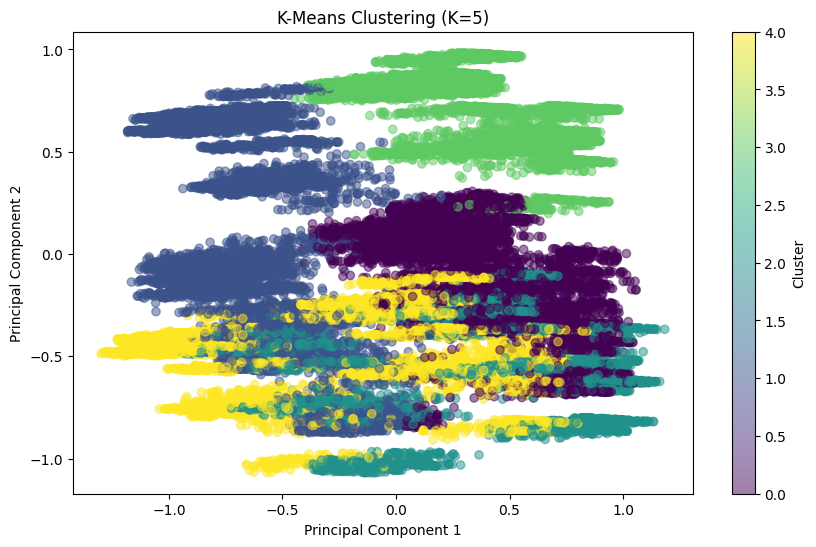

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    df_pca['PC1'],
    df_pca['PC2'],
    c=df_pca['Cluster'],
    cmap='viridis',
    alpha=0.5
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('K-Means Clustering (K=5)')

plt.colorbar(label='Cluster')

plt.show()

In [29]:
from sklearn.cluster import AgglomerativeClustering

# Use only PCA feature columns
pca_features = df_pca.drop(columns=['Cluster'], errors='ignore')

# Take a sample to avoid memory crash
sample_data = pca_features.sample(
    n=5000,
    random_state=42
)

# Agglomerative Clustering
agg = AgglomerativeClustering(
    n_clusters=5,
    linkage='ward'
)

agg_labels = agg.fit_predict(sample_data)

# Store cluster labels
sample_data = sample_data.copy()
sample_data['Agg_Cluster'] = agg_labels

# Check cluster counts
print(sample_data['Agg_Cluster'].value_counts().sort_index())

Agg_Cluster
0    2452
1    1008
2     663
3     437
4     440
Name: count, dtype: int64


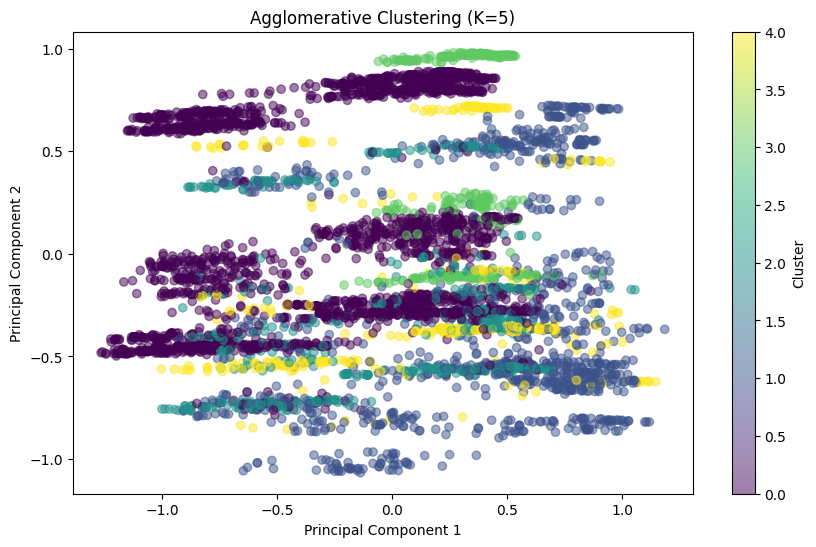

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    sample_data['PC1'],
    sample_data['PC2'],
    c=sample_data['Agg_Cluster'],
    cmap='viridis',
    alpha=0.5
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Agglomerative Clustering (K=5)')

plt.colorbar(label='Cluster')

plt.show()

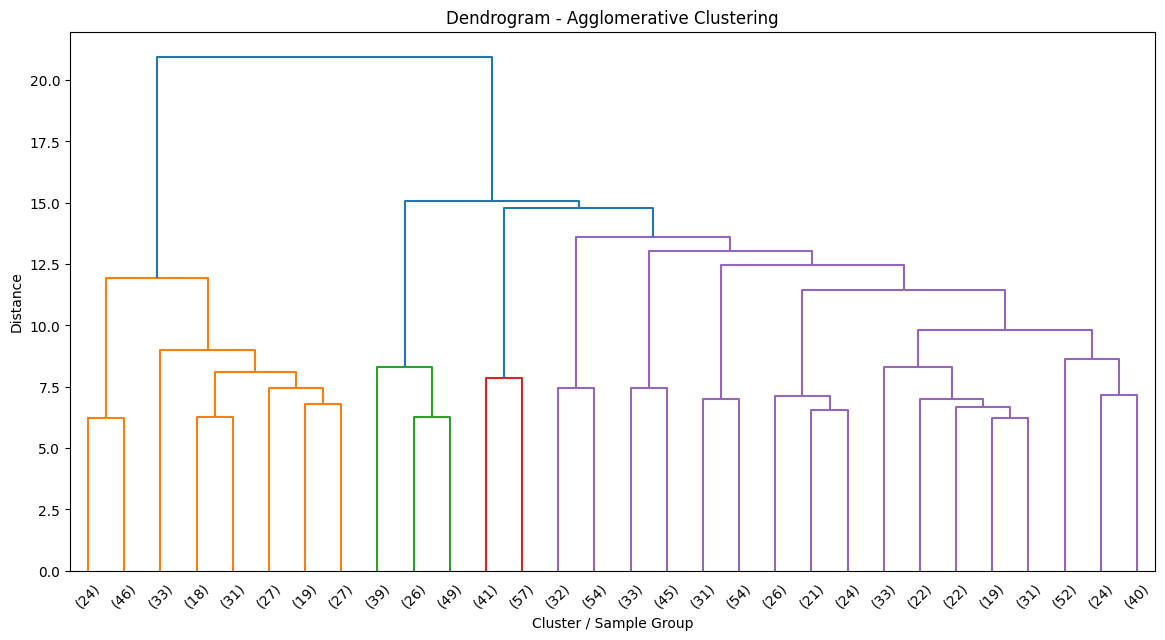

In [31]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# Take a smaller sample for dendrogram
dendro_sample = df_pca.drop(
    columns=['Cluster'],
    errors='ignore'
).sample(
    n=1000,
    random_state=42
)

# Create linkage matrix
Z = linkage(
    dendro_sample,
    method='ward'
)

# Plot dendrogram
plt.figure(figsize=(14, 7))

dendrogram(
    Z,
    truncate_mode='lastp',
    p=30
)

plt.title('Dendrogram - Agglomerative Clustering')
plt.xlabel('Cluster / Sample Group')
plt.ylabel('Distance')

plt.show()

In [32]:
df['Cluster'] = kmeans.labels_

cluster_counts = df['Cluster'].value_counts().sort_index()

print(cluster_counts)

print("\nPercentage:")
print((cluster_counts / len(df) * 100).round(2))

Cluster
0     9783
1     9476
2     8017
3    10688
4    10878
Name: count, dtype: int64

Percentage:
Cluster
0    20.03
1    19.40
2    16.41
3    21.88
4    22.27
Name: count, dtype: float64


In [33]:
df['income_clean'] = (
    df['income']
    .str.strip()
    .str.replace('.', '', regex=False)
)

income_profile = pd.crosstab(
    df['Cluster'],
    df['income_clean'],
    normalize='index'
) * 100

print(income_profile.round(2))

income_clean  <=50K   >50K
Cluster                   
0             67.28  32.72
1             90.09   9.91
2             58.70  41.30
3             79.67  20.33
4             81.04  18.96


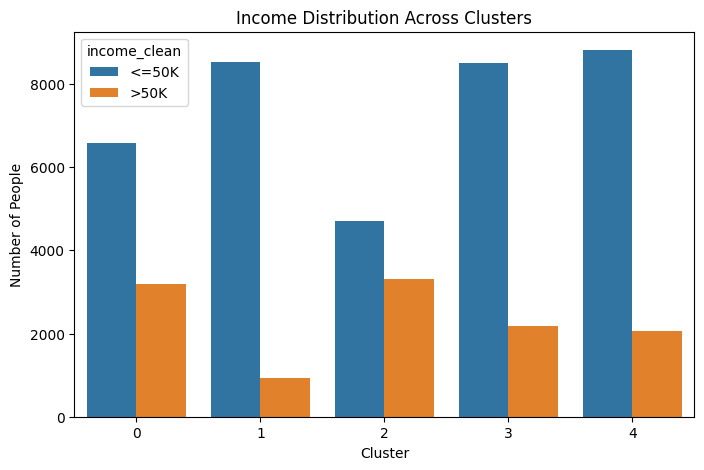

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='Cluster',
    hue='income_clean'
)

plt.title('Income Distribution Across Clusters')
plt.xlabel('Cluster')
plt.ylabel('Number of People')
plt.show()

Cluster 0:
This cluster contains approximately 52.55% of the dataset. It has a higher average age of around 45.8 years and is predominantly male. Most records are associated with married-couple relationships, particularly the Husband relationship category. Private-sector employment is common, along with occupations such as executive-managerial, professional-specialty, craft-repair, and sales. The average working time is approximately 43.9 hours per week. Around 41% of this cluster belongs to the >50K income category.

Cluster 1:
This cluster contains approximately 47.45% of the dataset. It has a lower average age of around 30.6 years and has a more balanced gender distribution. The majority of records are never married, with Not-in-family and Own-child being common relationship categories. Private-sector employment is dominant, with administrative-clerical, sales, professional-specialty, and craft-repair occupations being common. The average working time is approximately 38.2 hours per week. Around 5.1% of this cluster belongs to the >50K income category.